# Advertising & Sales Statistical Analysis

This project analyzes the relationship between advertising expenditure across **TV, Radio, and Newspaper** channels and product **Sales**.

The analysis combines exploratory data analysis with statistical and mathematical techniques to examine the structure of the advertising data and quantify its relationship with sales.

### Analysis Workflow

1. **Exploratory Data Analysis**
   - Data quality checks
   - Descriptive statistics
   - Distribution analysis
   - Outlier inspection
   - Correlation analysis

2. **Matrix Analysis & Dimensionality Reduction**
   - Covariance matrix
   - Eigenvalues and eigenvectors
   - Singular Value Decomposition (SVD)
   - Principal component loadings
   - Explained variance
   - Reduction from three advertising dimensions to two

3. **Linear Regression & Statistical Inference**
   - Regression coefficients using the SVD pseudo-inverse
   - Standard errors
   - t-statistics and p-values
   - Model performance metrics
   - Standardized coefficients
   - Residual diagnostics

4. **Bayesian Analysis**
   - Definition of high-sales observations
   - Beta prior and posterior updating
   - Posterior probability estimate
   - 95% credible interval

---

**Tools:** Python, Pandas, NumPy, Matplotlib, SciPy  
**Course:** Statistics & Mathematics for Data Analysts — MCI Academy

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import beta as beta_dist


# -------------------------
# Project paths
# -------------------------

current_dir = Path.cwd()

if current_dir.name == "notebook":
    project_root = current_dir.parent
elif (current_dir / "notebook").exists():
    project_root = current_dir
else:
    project_root = current_dir

assets_dir = project_root / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Locate and load the dataset
# -------------------------

data_candidates = [
    project_root / "data" / "Advertising.csv",
    current_dir / "advertising_Dataset.csv",
    current_dir / "Advertising.csv"
]

data_path = next(
    (path for path in data_candidates if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "Advertising dataset not found. "
        "Download Advertising.csv and place it in the data/ directory."
    )

df = pd.read_csv(data_path)

# Remove the redundant index column if present
df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)


# -------------------------
# Basic dataset information
# -------------------------

print(
    f"Dataset shape: "
    f"{df.shape[0]} rows × "
    f"{df.shape[1]} columns"
)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: 200 rows × 4 columns

Columns:
['TV', 'Radio', 'Newspaper', 'Sales']

First 5 rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 1. Exploratory Data Analysis

The first stage examines the structure, completeness, and distribution of the dataset.

The analysis focuses on four variables:

- **TV** — advertising expenditure on television
- **Radio** — advertising expenditure on radio
- **Newspaper** — advertising expenditure on newspapers
- **Sales** — observed product sales

The objective is to identify data-quality issues, understand the distribution of each variable, inspect potential outliers, and examine initial relationships between advertising expenditure and sales.

Data Quality Summary:


,data_type,missing_values,missing_pct,unique_values
TV,float64,0,0.0,190
Radio,float64,0,0.0,167
Newspaper,float64,0,0.0,172
Sales,float64,0,0.0,121



Duplicate rows: 0

Descriptive Statistics:


,count,mean,median,std,variance,min,max,skewness
TV,200,147.042,149.75,85.854,7370.950,0.7,296.4,-0.070
Radio,200,23.264,22.90,14.847,220.428,0.0,49.6,0.094
Newspaper,200,30.554,25.75,21.779,474.308,0.3,114.0,0.895
Sales,200,14.022,12.90,5.217,27.222,1.6,27.0,0.408


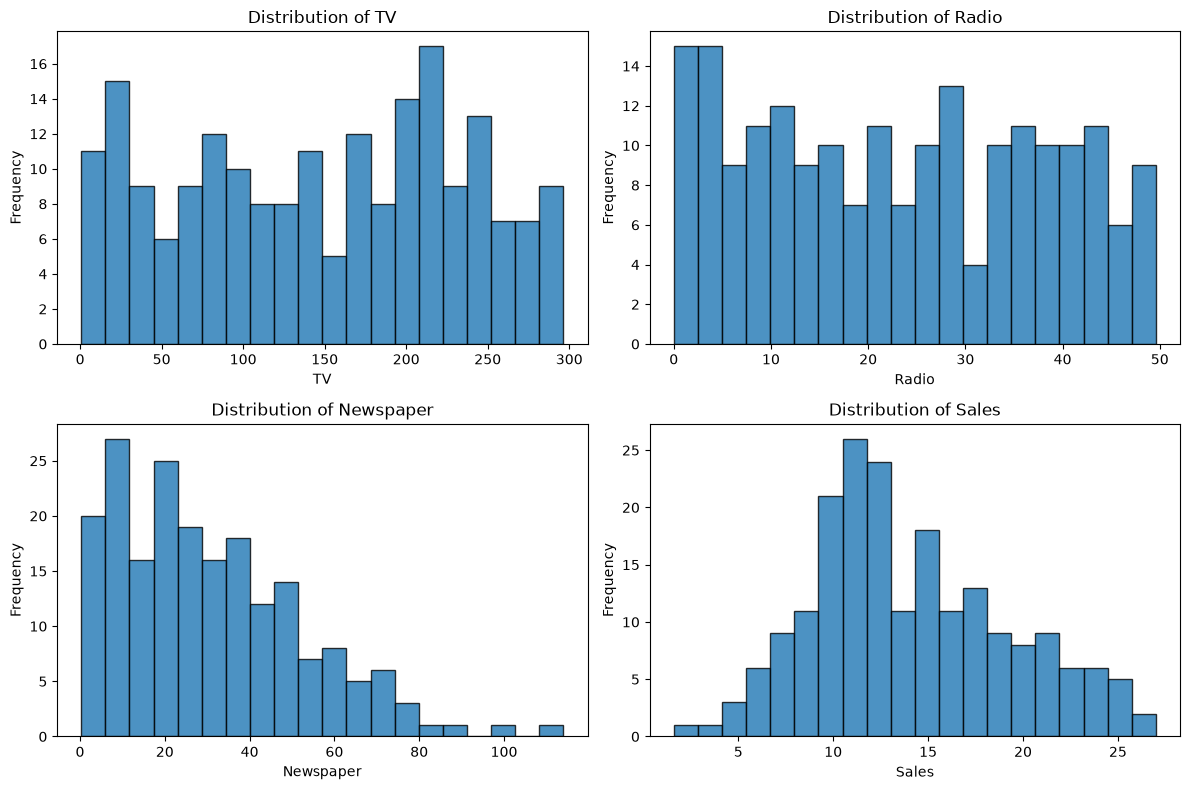

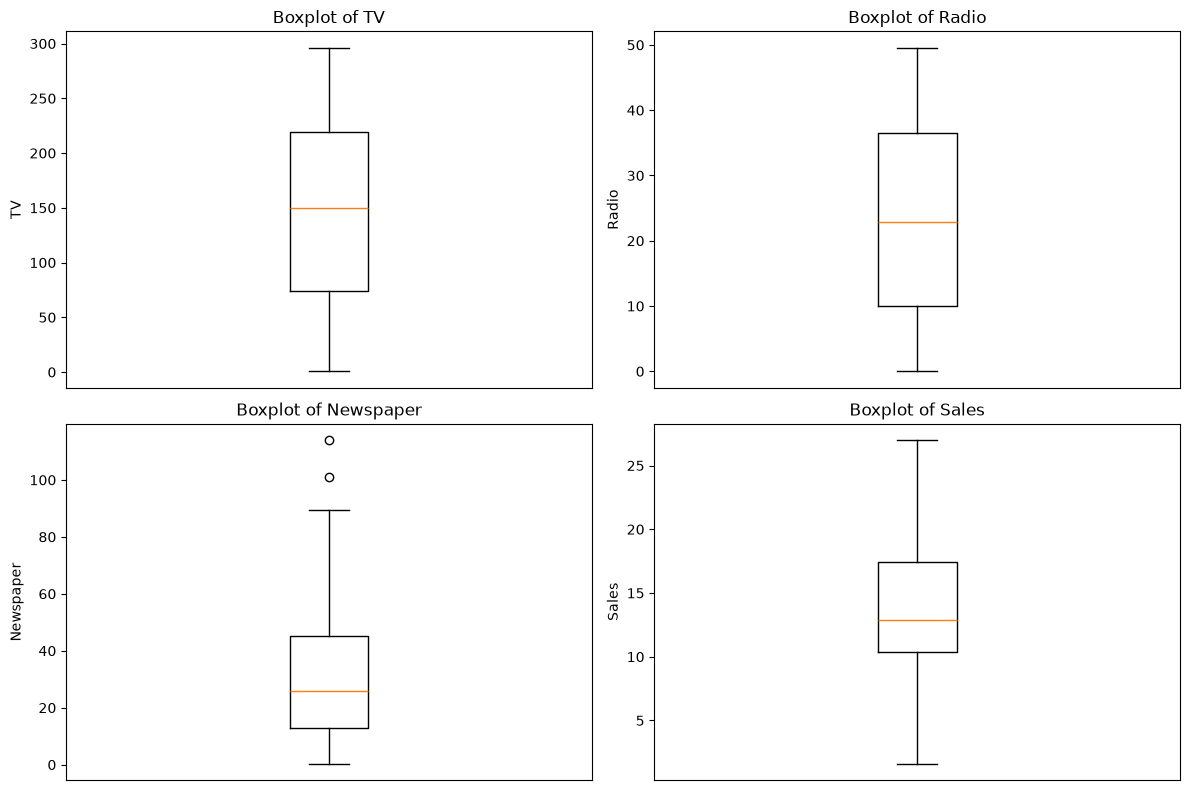

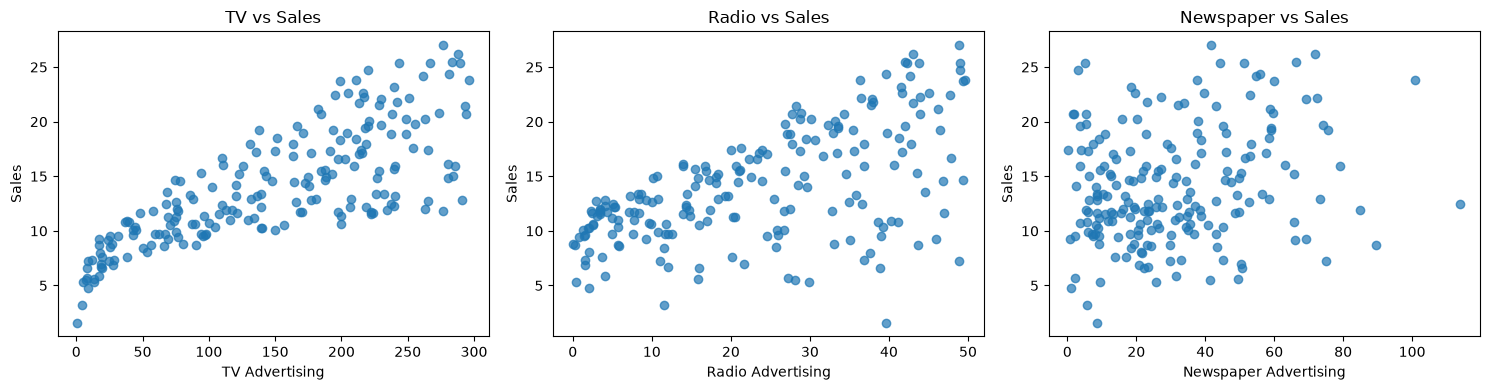

Correlation Matrix:


,TV,Radio,Newspaper,Sales
TV,1.000,0.055,0.057,0.782
Radio,0.055,1.000,0.354,0.576
Newspaper,0.057,0.354,1.000,0.228
Sales,0.782,0.576,0.228,1.000


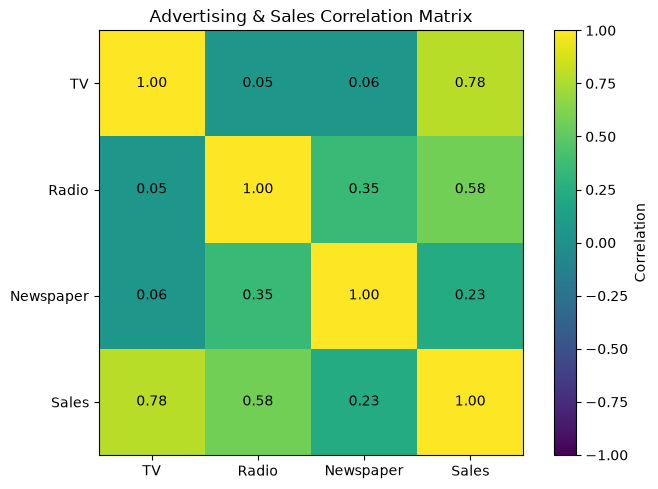

In [2]:
# Select columns used in the analysis
analysis_columns = ["TV", "Radio", "Newspaper", "Sales"]


# -------------------------
# Data quality checks
# -------------------------

quality_summary = pd.DataFrame({
    "data_type": df[analysis_columns].dtypes.astype(str),
    "missing_values": df[analysis_columns].isna().sum(),
    "missing_pct": (
        df[analysis_columns].isna().mean() * 100
    ).round(2),
    "unique_values": df[analysis_columns].nunique()
})

print("Data Quality Summary:")
display(quality_summary)

duplicate_rows = df.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_rows}")


# -------------------------
# Descriptive statistics
# -------------------------

descriptive_stats = pd.DataFrame({
    "count": df[analysis_columns].count(),
    "mean": df[analysis_columns].mean(),
    "median": df[analysis_columns].median(),
    "std": df[analysis_columns].std(),
    "variance": df[analysis_columns].var(),
    "min": df[analysis_columns].min(),
    "max": df[analysis_columns].max(),
    "skewness": df[analysis_columns].skew()
}).round(3)

print("\nDescriptive Statistics:")
display(descriptive_stats)


# -------------------------
# Distribution plots
# -------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), analysis_columns):
    ax.hist(
        df[column],
        bins=20,
        edgecolor="black",
        alpha=0.8
    )

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# -------------------------
# Boxplots for outlier inspection
# -------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), analysis_columns):
    ax.boxplot(
        df[column],
        orientation="vertical"
    )

    ax.set_title(f"Boxplot of {column}")
    ax.set_ylabel(column)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


# -------------------------
# Advertising channels vs Sales
# -------------------------

advertising_channels = ["TV", "Radio", "Newspaper"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, channel in zip(axes, advertising_channels):
    ax.scatter(
        df[channel],
        df["Sales"],
        alpha=0.7
    )

    ax.set_title(f"{channel} vs Sales")
    ax.set_xlabel(f"{channel} Advertising")
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()


# -------------------------
# Correlation analysis
# -------------------------

correlation_matrix = df[analysis_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(analysis_columns)))
ax.set_yticks(range(len(analysis_columns)))

ax.set_xticklabels(analysis_columns)
ax.set_yticklabels(analysis_columns)

for i in range(len(analysis_columns)):
    for j in range(len(analysis_columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Advertising & Sales Correlation Matrix")

plt.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()

plt.savefig(
    assets_dir / "advertising-sales-correlations.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### EDA Findings

The dataset contains **200 observations** and four analytical variables: `TV`, `Radio`, `Newspaper`, and `Sales`.

No missing values or duplicate rows were identified, so no additional data-cleaning step was required before the statistical analysis.

#### Distribution Insights

- `TV` and `Radio` are approximately symmetric, with skewness values close to zero.
- `Newspaper` shows the strongest positive skewness (`0.895`), indicating a longer right tail and greater concentration of high-value observations.
- `Sales` is moderately right-skewed (`0.408`) but remains relatively well distributed across the observed range.

#### Relationships with Sales

The correlation analysis shows clear differences between advertising channels:

- **TV vs Sales:** `0.78` — strong positive linear relationship
- **Radio vs Sales:** `0.58` — moderate positive linear relationship
- **Newspaper vs Sales:** `0.23` — weak positive linear relationship

TV therefore shows the strongest univariate association with Sales, followed by Radio.

Newspaper has a substantially weaker relationship with Sales, suggesting that its contribution may be limited once all advertising channels are considered jointly in the regression model.

These correlations describe association rather than causation. The regression and statistical inference sections will be used to evaluate each channel while controlling for the others.

## 2. Matrix Analysis & Dimensionality Reduction

The three advertising variables (`TV`, `Radio`, and `Newspaper`) are analyzed using linear algebra to examine their multivariate structure.

Because the advertising channels are measured on different numerical scales, the variables are standardized before matrix decomposition.

This section includes:

- Covariance analysis of the standardized advertising variables
- Eigenvalue and eigenvector decomposition
- Singular Value Decomposition (SVD)
- Principal component loadings
- Explained variance analysis
- Projection of the original three-dimensional advertising data into two dimensions

The objective is to determine how much of the original variation can be retained using fewer dimensions and to identify which advertising channels contribute most strongly to each component.

Standardized Data Preview:


,TV,Radio,Newspaper
0,0.969852,0.981522,1.778945
1,-1.197376,1.082808,0.669579
2,-1.516155,1.528463,1.783549
3,0.052050,1.217855,1.286405
4,0.394182,-0.841614,1.281802



Covariance Matrix:


,TV,Radio,Newspaper
TV,1.005,0.055,0.057
Radio,0.055,1.005,0.356
Newspaper,0.057,0.356,1.005



Eigenvalue Summary:


...


Principal Component Loadings:


,PC1,PC2,PC3
TV,-0.2079,-0.9781,0.0038
Radio,-0.6914,0.1497,0.7068
Newspaper,-0.6919,0.1443,-0.7074



Explained Variance:


,component,explained_variance_pct,cumulative_variance_pct
0,PC1,45.70,45.70
1,PC2,32.78,78.47
2,PC3,21.53,100.00


Variance retained by PC1 + PC2: 78.47%


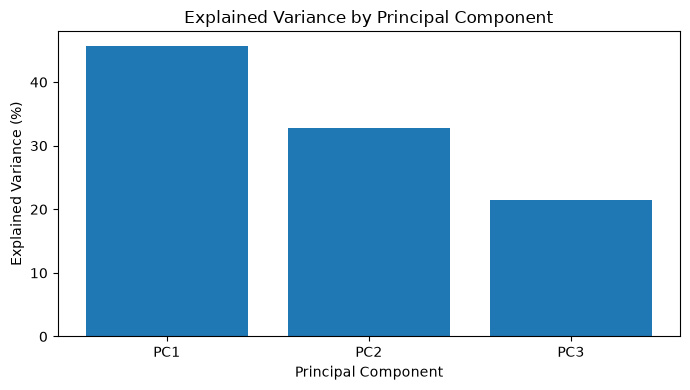


Reduced Data Shape:
(200, 2)

Reduced Data Preview:


,PC1,PC2
0,-2.111124,-0.545027
1,-0.963044,1.429895
2,-1.975686,1.969174
3,-1.742935,0.317004
4,-0.386961,-0.326528


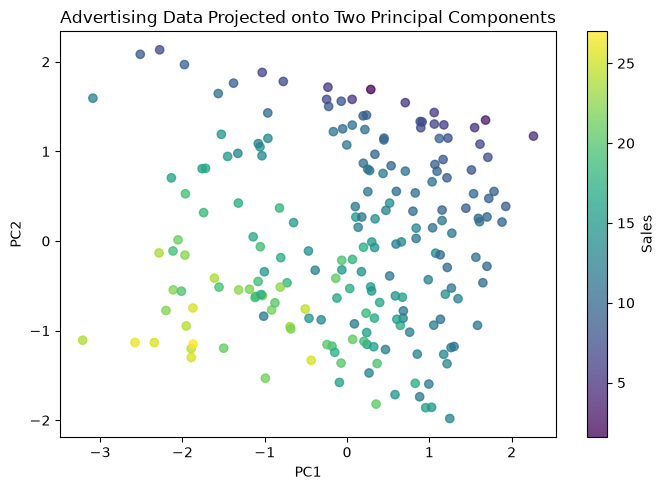

In [3]:
# Advertising variables used for dimensionality reduction
features = ["TV", "Radio", "Newspaper"]

X = df[features].to_numpy()


# -------------------------
# Standardize the variables
# -------------------------

feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0, ddof=0)

Z = (X - feature_mean) / feature_std

standardized_df = pd.DataFrame(
    Z,
    columns=features
)

print("Standardized Data Preview:")
display(standardized_df.head())


# -------------------------
# Covariance matrix
# -------------------------

cov_matrix = np.cov(
    Z,
    rowvar=False
)

covariance_df = pd.DataFrame(
    cov_matrix,
    index=features,
    columns=features
)

print("\nCovariance Matrix:")
display(covariance_df.round(3))


# -------------------------
# Eigenvalue decomposition
# -------------------------

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort components from largest to smallest eigenvalue
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

eigenvalue_summary = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3"],
    "eigenvalue": eigenvalues,
    "explained_variance_ratio": (
        eigenvalues / eigenvalues.sum()
    )
})

print("\nEigenvalue Summary:")
display(eigenvalue_summary.round(4))

eigenvector_df = pd.DataFrame(
    eigenvectors,
    index=features,
    columns=["PC1", "PC2", "PC3"]
)

print("\nEigenvectors:")
display(eigenvector_df.round(4))


# -------------------------
# Singular Value Decomposition
# -------------------------

U, singular_values, VT = np.linalg.svd(
    Z,
    full_matrices=False
)

explained_variance = (
    singular_values ** 2
    / (len(Z) - 1)
)

explained_ratio = (
    explained_variance
    / explained_variance.sum()
)

cumulative_variance = np.cumsum(
    explained_ratio
)


# -------------------------
# Principal component loadings
# -------------------------

loadings = pd.DataFrame(
    VT.T,
    index=features,
    columns=["PC1", "PC2", "PC3"]
)

print("\nPrincipal Component Loadings:")
display(loadings.round(4))


# -------------------------
# Explained variance summary
# -------------------------

variance_summary = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3"],
    "explained_variance_pct": (
        explained_ratio * 100
    ),
    "cumulative_variance_pct": (
        cumulative_variance * 100
    )
})

print("\nExplained Variance:")
display(variance_summary.round(2))

print(
    "Variance retained by PC1 + PC2: "
    f"{cumulative_variance[1] * 100:.2f}%"
)


# -------------------------
# Explained variance plot
# -------------------------

components = ["PC1", "PC2", "PC3"]

plt.figure(figsize=(7, 4))

plt.bar(
    components,
    explained_ratio * 100
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Component")

plt.tight_layout()

plt.savefig(
    assets_dir / "svd-explained-variance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# Reduce the data from 3D to 2D
# -------------------------

X_reduced = Z @ VT[:2].T

reduced_df = pd.DataFrame(
    X_reduced,
    columns=["PC1", "PC2"]
)

print("\nReduced Data Shape:")
print(reduced_df.shape)

print("\nReduced Data Preview:")
display(reduced_df.head())


# -------------------------
# Visualize the reduced data
# -------------------------

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    reduced_df["PC1"],
    reduced_df["PC2"],
    c=df["Sales"],
    alpha=0.75
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "Advertising Data Projected onto Two Principal Components"
)

plt.colorbar(
    scatter,
    label="Sales"
)

plt.tight_layout()
plt.show()

### Matrix & SVD Findings

The standardized advertising variables were decomposed using both eigenvalue analysis and Singular Value Decomposition (SVD).

#### Explained Variance

The three principal components explain:

- **PC1:** `45.70%`
- **PC2:** `32.78%`
- **PC3:** `21.53%`

Together, the first two components retain **78.47% of the total variance** in the three advertising variables.

This indicates that the original three-dimensional advertising space can be represented in two dimensions while preserving most, but not all, of its variability.

#### Component Interpretation

The absolute component loadings show that:

- **PC1** is driven primarily by `Radio` and `Newspaper`, with absolute loadings of approximately `0.69` for both variables.
- **PC2** is dominated by `TV`, with an absolute loading of approximately `0.98`.
- **PC3** mainly contrasts `Radio` and `Newspaper`.

The signs of SVD component loadings are direction-dependent and may be reversed without changing the underlying component. Therefore, the magnitude of the loadings is used here to interpret each variable's contribution.

Overall, the decomposition reveals that TV behaves differently from the Radio–Newspaper combination in the multivariate advertising structure.

## 3. Linear Regression & Statistical Inference

A multiple linear regression model is used to estimate Sales from the three advertising channels:

\[
Sales = \beta_0 + \beta_1(TV) + \beta_2(Radio) + \beta_3(Newspaper) + \varepsilon
\]

Rather than relying on a high-level regression library, the coefficients are estimated directly using the **Singular Value Decomposition (SVD) pseudo-inverse** of the design matrix.

The analysis includes:

- Regression coefficient estimation
- Standard errors
- t-statistics
- p-values
- 95% confidence intervals
- \(R^2\) and adjusted \(R^2\)
- RMSE and MAE
- Standardized coefficients
- Actual vs. predicted values
- Residual diagnostics

The statistical inference evaluates each advertising channel while controlling for the other channels in the model.

Regression Coefficient Summary:


,coefficient,std_error,t_statistic,p_value,ci_95_lower,ci_95_upper
Intercept,2.938889,0.311908,9.422288,1.267e-17,2.323762,3.554016
TV,0.045765,0.001395,32.808624,1.510e-81,0.043014,0.048516
Radio,0.188530,0.008611,21.893496,1.505e-54,0.171547,0.205513
Newspaper,-0.001037,0.005871,-0.176715,8.599e-01,-0.012616,0.010541



Model Performance:


,metric,value
0,R-squared,0.8972
1,Adjusted R-squared,0.8956
2,RMSE,1.6686
3,MAE,1.2520



Standardized Coefficients:


,predictor,standardized_coefficient,absolute_standardized_coefficient
0,TV,0.7531,0.7531
1,Radio,0.5365,0.5365
2,Newspaper,-0.0043,0.0043


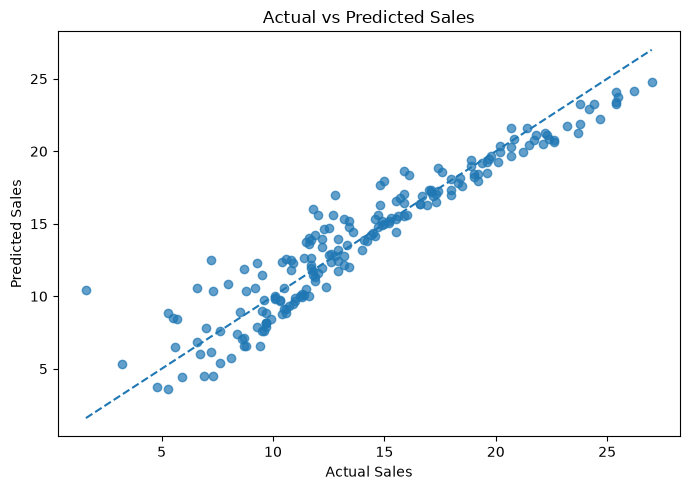

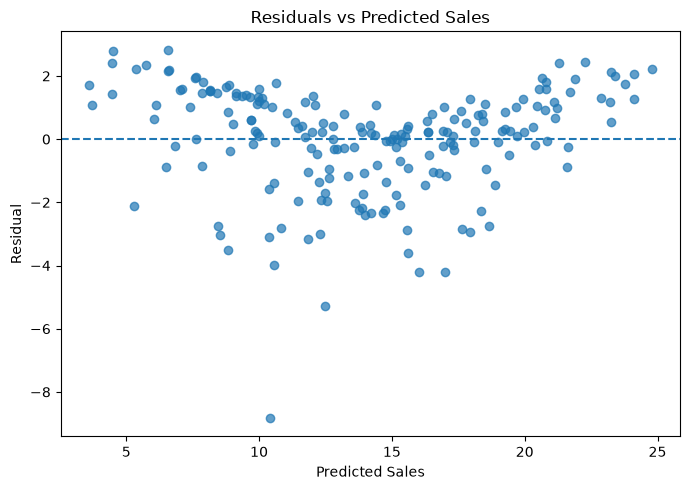

In [4]:
# Predictor variables and target
predictors = ["TV", "Radio", "Newspaper"]

X_reg = df[predictors].to_numpy()
y = df["Sales"].to_numpy()

n = len(y)
k = len(predictors)


# -------------------------
# Build the design matrix
# -------------------------

X_design = np.column_stack([
    np.ones(n),
    X_reg
])

parameter_names = [
    "Intercept",
    "TV",
    "Radio",
    "Newspaper"
]


# -------------------------
# Estimate coefficients using SVD pseudo-inverse
# -------------------------

U_reg, S_reg, VT_reg = np.linalg.svd(
    X_design,
    full_matrices=False
)

tolerance = (
    np.finfo(float).eps
    * max(X_design.shape)
    * S_reg.max()
)

S_inv = np.array([
    1 / value if value > tolerance else 0
    for value in S_reg
])

X_pseudo = (
    VT_reg.T
    @ np.diag(S_inv)
    @ U_reg.T
)

beta = X_pseudo @ y


# -------------------------
# Predictions and residuals
# -------------------------

y_pred = X_design @ beta
residuals = y - y_pred

df_residual = n - (k + 1)

sse = np.sum(residuals ** 2)
mse = sse / df_residual


# -------------------------
# Standard errors
# -------------------------

xtx_inverse = np.linalg.pinv(
    X_design.T @ X_design
)

coefficient_covariance = (
    mse * xtx_inverse
)

standard_errors = np.sqrt(
    np.diag(coefficient_covariance)
)


# -------------------------
# t-statistics and p-values
# -------------------------

t_statistics = (
    beta / standard_errors
)

p_values = (
    2
    * stats.t.sf(
        np.abs(t_statistics),
        df=df_residual
    )
)


# -------------------------
# 95% confidence intervals
# -------------------------

t_critical = stats.t.ppf(
    0.975,
    df=df_residual
)

ci_lower = (
    beta
    - t_critical * standard_errors
)

ci_upper = (
    beta
    + t_critical * standard_errors
)


# -------------------------
# Regression summary
# -------------------------

regression_summary = pd.DataFrame({
    "coefficient": beta,
    "std_error": standard_errors,
    "t_statistic": t_statistics,
    "p_value": p_values,
    "ci_95_lower": ci_lower,
    "ci_95_upper": ci_upper
}, index=parameter_names)

regression_summary_display = (
    regression_summary.copy()
)

numeric_columns = [
    "coefficient",
    "std_error",
    "t_statistic",
    "ci_95_lower",
    "ci_95_upper"
]

regression_summary_display[
    numeric_columns
] = regression_summary_display[
    numeric_columns
].round(6)

regression_summary_display[
    "p_value"
] = regression_summary[
    "p_value"
].map(
    lambda value: f"{value:.3e}"
)

print("Regression Coefficient Summary:")
display(regression_summary_display)


# -------------------------
# Model performance
# -------------------------

sst = np.sum(
    (y - y.mean()) ** 2
)

r_squared = 1 - (sse / sst)

adjusted_r_squared = (
    1
    - (1 - r_squared)
    * (n - 1)
    / df_residual
)

rmse = np.sqrt(
    np.mean(residuals ** 2)
)

mae = np.mean(
    np.abs(residuals)
)

model_metrics = pd.DataFrame({
    "metric": [
        "R-squared",
        "Adjusted R-squared",
        "RMSE",
        "MAE"
    ],
    "value": [
        r_squared,
        adjusted_r_squared,
        rmse,
        mae
    ]
})

print("\nModel Performance:")
display(
    model_metrics.round(4)
)


# -------------------------
# Standardized coefficients
# -------------------------

x_std = df[predictors].std(
    ddof=0
).to_numpy()

y_std = df["Sales"].std(
    ddof=0
)

standardized_beta = (
    beta[1:]
    * x_std
    / y_std
)

standardized_summary = pd.DataFrame({
    "predictor": predictors,
    "standardized_coefficient": standardized_beta
})

standardized_summary[
    "absolute_standardized_coefficient"
] = np.abs(
    standardized_summary[
        "standardized_coefficient"
    ]
)

standardized_summary = (
    standardized_summary
    .sort_values(
        "absolute_standardized_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nStandardized Coefficients:")
display(
    standardized_summary.round(4)
)


# -------------------------
# Actual vs predicted sales
# -------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y,
    y_pred,
    alpha=0.7
)

prediction_min = min(
    y.min(),
    y_pred.min()
)

prediction_max = max(
    y.max(),
    y_pred.max()
)

plt.plot(
    [prediction_min, prediction_max],
    [prediction_min, prediction_max],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()

plt.savefig(
    assets_dir / "actual-vs-predicted-sales.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# Residual diagnostic
# -------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Sales")

plt.tight_layout()
plt.show()

### Regression Findings

The multiple linear regression model explains approximately **89.7% of the observed variation in Sales** (`R² = 0.897`), with an adjusted `R²` of approximately `0.896`.

The model produces an RMSE of approximately `1.67` and an MAE of approximately `1.25` Sales units.

#### Statistical Significance

After controlling for the other advertising channels:

- **TV** has a positive and statistically significant coefficient (`β ≈ 0.0458`).
- **Radio** also has a positive and statistically significant coefficient (`β ≈ 0.1885`).
- **Newspaper** has a coefficient close to zero (`β ≈ -0.0010`) and is not statistically significant (`p ≈ 0.860`).

The 95% confidence interval for Newspaper includes zero, providing further evidence that its independent contribution is not distinguishable from zero in this linear model.

#### Relative Predictor Importance

Raw regression coefficients should not be compared directly because the advertising variables are measured on different numerical scales.

Using standardized coefficients provides a more comparable measure of relative association:

- **TV:** `0.753`
- **Radio:** `0.537`
- **Newspaper:** `-0.004`

TV therefore shows the strongest standardized association with Sales, followed by Radio, while Newspaper contributes very little after the other channels are controlled for.

These results describe statistical associations within the observed dataset and should not be interpreted as evidence of causal advertising effects.

## 4. Bayesian Analysis of High-Sales Probability

A Bayesian model is used to estimate the probability that an observation represents a **high-sales** outcome.

High sales are defined as observations where `Sales` is greater than the sample median.

A uniform Beta prior is used:

\[
p \sim Beta(1, 1)
\]

where \(p\) represents the probability of observing a high-sales outcome.

After observing the data, the prior distribution is updated to obtain the posterior distribution.

This section reports:

- The high-sales threshold
- Number and proportion of high-sales observations
- Prior and posterior Beta parameters
- Posterior mean
- 95% Bayesian credible interval
- Posterior probability distribution

Bayesian Analysis Summary:


,metric,value
0,Median Sales Threshold,12.9000
1,Total Observations,200.0000
2,High Sales Count,98.0000
3,Observed High Sales Rate,0.4900
4,Prior Alpha,1.0000
5,Prior Beta,1.0000
6,Posterior Alpha,99.0000
7,Posterior Beta,103.0000
8,Posterior Mean,0.4901
9,95% Credible Interval Lower,0.4215


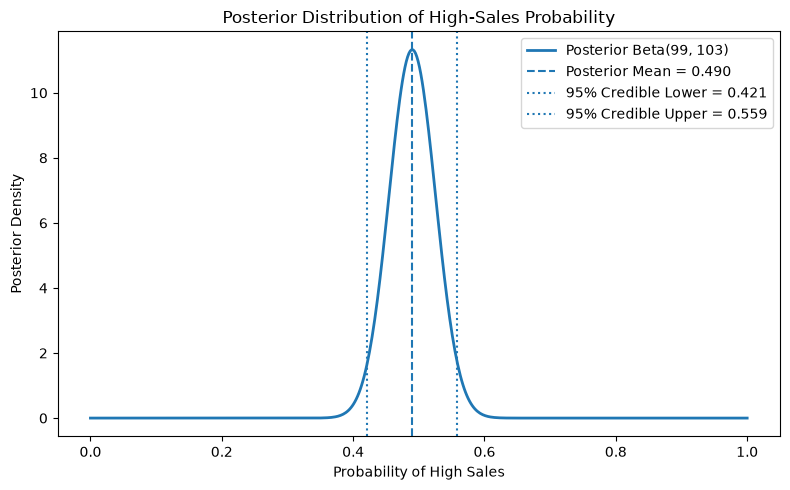

In [5]:
# Sales observations
sales = df["Sales"]

# -------------------------
# Define high-sales observations
# -------------------------

median_sales = sales.median()

high_sales = sales > median_sales

n_observations = len(sales)
high_sales_count = int(high_sales.sum())
low_sales_count = n_observations - high_sales_count

observed_high_sales_rate = (
    high_sales_count / n_observations
)


# -------------------------
# Define Beta prior
# -------------------------

alpha_prior = 1
beta_prior = 1


# -------------------------
# Update posterior distribution
# -------------------------

alpha_posterior = (
    alpha_prior + high_sales_count
)

beta_posterior = (
    beta_prior + low_sales_count
)


# -------------------------
# Posterior statistics
# -------------------------

posterior_mean = (
    alpha_posterior
    / (alpha_posterior + beta_posterior)
)

credible_interval = beta_dist.ppf(
    [0.025, 0.975],
    alpha_posterior,
    beta_posterior
)

credible_lower = credible_interval[0]
credible_upper = credible_interval[1]


# -------------------------
# Bayesian summary
# -------------------------

bayesian_summary = pd.DataFrame({
    "metric": [
        "Median Sales Threshold",
        "Total Observations",
        "High Sales Count",
        "Observed High Sales Rate",
        "Prior Alpha",
        "Prior Beta",
        "Posterior Alpha",
        "Posterior Beta",
        "Posterior Mean",
        "95% Credible Interval Lower",
        "95% Credible Interval Upper"
    ],
    "value": [
        median_sales,
        n_observations,
        high_sales_count,
        observed_high_sales_rate,
        alpha_prior,
        beta_prior,
        alpha_posterior,
        beta_posterior,
        posterior_mean,
        credible_lower,
        credible_upper
    ]
})

print("Bayesian Analysis Summary:")
display(
    bayesian_summary.round(4)
)


# -------------------------
# Posterior distribution
# -------------------------

probability_grid = np.linspace(
    0,
    1,
    500
)

posterior_density = beta_dist.pdf(
    probability_grid,
    alpha_posterior,
    beta_posterior
)

plt.figure(figsize=(8, 5))

plt.plot(
    probability_grid,
    posterior_density,
    linewidth=2,
    label=(
        f"Posterior Beta("
        f"{alpha_posterior}, "
        f"{beta_posterior})"
    )
)

plt.axvline(
    posterior_mean,
    linestyle="--",
    label=(
        f"Posterior Mean = "
        f"{posterior_mean:.3f}"
    )
)

plt.axvline(
    credible_lower,
    linestyle=":",
    label=(
        f"95% Credible Lower = "
        f"{credible_lower:.3f}"
    )
)

plt.axvline(
    credible_upper,
    linestyle=":",
    label=(
        f"95% Credible Upper = "
        f"{credible_upper:.3f}"
    )
)

plt.xlabel("Probability of High Sales")
plt.ylabel("Posterior Density")
plt.title(
    "Posterior Distribution of High-Sales Probability"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    assets_dir / "bayesian-posterior.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Bayesian Findings

High sales were defined as observations with `Sales` greater than the sample median of `12.9`.

Among the 200 observations:

- **98 observations** were classified as high sales.
- The observed high-sales rate was **49.0%**.

Using a uniform prior:

\[
p \sim Beta(1,1)
\]

the posterior distribution becomes:

\[
p \mid data \sim Beta(99,103)
\]

The posterior mean is approximately **0.490**, indicating that the estimated probability of a high-sales observation is about **49.0%**.

The **95% Bayesian credible interval** is approximately:

\[
[0.422,\ 0.559]
\]

This means that, under the specified Beta-Binomial model, the posterior probability that the true high-sales rate lies between approximately **42.2% and 55.9%** is 95%.

Because the prior is weak relative to the 200 observed samples, the posterior mean remains very close to the observed high-sales proportion.

## 5. Final Conclusions

This analysis combined exploratory statistics, linear algebra, regression inference, and Bayesian estimation to examine the relationship between advertising expenditure and Sales.

### Key Findings

- The dataset contains **200 observations** with no missing values or duplicate rows.
- `TV` shows the strongest simple correlation with Sales (`r ≈ 0.78`), followed by `Radio` (`r ≈ 0.58`).
- `Newspaper` has a substantially weaker relationship with Sales (`r ≈ 0.23`).

### Dimensionality Reduction

SVD showed that:

- `PC1` explains approximately **45.7%** of the variance.
- `PC2` explains approximately **32.8%**.
- Together, the first two components preserve approximately **78.5%** of the variability in the three advertising channels.

The component loadings indicate that `Radio` and `Newspaper` dominate PC1, while `TV` dominates PC2.

### Regression Analysis

The multiple linear regression model explains approximately **89.7% of the variation in Sales** (`R² ≈ 0.897`).

After controlling for the other channels:

- `TV` has a positive and statistically significant association with Sales.
- `Radio` also has a positive and statistically significant association with Sales.
- `Newspaper` is not statistically significant (`p ≈ 0.860`).

Standardized coefficients show that `TV` has the strongest relative association with Sales, followed by `Radio`.

### Bayesian Analysis

Using the median Sales value (`12.9`) as the high-sales threshold:

- 98 of 200 observations were classified as high sales.
- The posterior distribution is `Beta(99, 103)`.
- The posterior mean probability of high sales is approximately **49.0%**.
- The 95% credible interval is approximately **42.2% to 55.9%**.

### Overall Takeaway

The results consistently identify `TV` and `Radio` as the advertising channels most strongly associated with Sales in this dataset, while `Newspaper` provides little additional predictive information after controlling for the other channels.

The analysis demonstrates how exploratory statistics, matrix decomposition, regression inference, and Bayesian methods can be combined to provide complementary perspectives on the same business problem.

> These results describe statistical associations in the observed data and should not be interpreted as causal effects.